<a href="https://colab.research.google.com/github/Angecarine/BUSSINESS-INTELLIGENT-ASSIGNMENT-1-NIYONSENGA-ANGE-CARINE-223004810/blob/main/Business_Intelligence_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
from google.colab import files
uploaded = files.upload()

Saving BI_Retail_Case_Study.xlsx to BI_Retail_Case_Study.xlsx


In [3]:
import pandas as pd
import numpy as np

# Load the Excel file
file_path = "BI_Retail_Case_Study.xlsx"

# Read SalesRaw sheet
sales = pd.read_excel(file_path, sheet_name="SalesRaw")

# Display columns
print(sales.columns.tolist())

# Convert TransactionDate to date format
sales["TransactionDate"] = pd.to_datetime(sales["TransactionDate"])

# Customer-level analysis
customer_value = sales.groupby("CustomerID").agg(
    Total_Revenue=("NetSales", "sum"),
    Number_of_Transactions=("TransactionID", "nunique"),
    First_Purchase=("TransactionDate", "min"),
    Last_Purchase=("TransactionDate", "max")
).reset_index()

# Calculate Lifetime Days
customer_value["Lifetime_Days"] = (
    customer_value["Last_Purchase"] -
    customer_value["First_Purchase"]
).dt.days

# Replace 0 with 1
customer_value["Lifetime_Days"] = customer_value["Lifetime_Days"].replace(0, 1)

# Calculate Average Order Value
customer_value["Average_Order_Value"] = (
    customer_value["Total_Revenue"] /
    customer_value["Number_of_Transactions"]
)

# Calculate Revenue per Day
customer_value["Revenue_per_Day"] = (
    customer_value["Total_Revenue"] /
    customer_value["Lifetime_Days"]
)

# Display results
customer_value.head(10)

['TransactionID', 'TransactionDate', 'StoreID', 'EmployeeID', 'CustomerID', 'ProductID', 'Quantity', 'UnitPrice', 'DiscountPct', 'SalesChannel', 'PaymentMethod', 'GrossSales', 'DiscountAmount', 'NetSales']


,CustomerID,Total_Revenue,Number_of_Transactions,First_Purchase,Last_Purchase,Lifetime_Days,Average_Order_Value,Revenue_per_Day
0,10001,227250.84,4,2025-01-20,2025-07-09,170,56812.710000,1336.769647
1,10002,104242.04,5,2025-02-25,2025-11-17,265,20848.408000,393.366189
2,10003,33632.85,1,2025-08-22,2025-08-22,1,33632.850000,33632.850000
3,10004,231642.98,6,2025-05-22,2025-12-25,217,38607.163333,1067.479171
4,10005,141817.25,4,2025-02-25,2025-10-13,230,35454.312500,616.596739
5,10006,93545.80,5,2025-02-26,2025-10-20,236,18709.160000,396.380508
6,10007,61671.86,3,2025-09-24,2025-12-03,70,20557.286667,881.026571
7,10008,368804.18,9,2025-03-03,2025-12-18,290,40978.242222,1271.738552
8,10009,157205.00,1,2025-12-13,2025-12-13,1,157205.000000,157205.000000
9,10010,106570.00,6,2025-03-22,2025-11-12,235,17761.666667,453.489362


In [12]:
products = pd.read_excel(file_path, sheet_name="DimProduct")
products.head()

['SalesRaw', 'DimProduct', 'DimCustomer', 'DimStore', 'DimEmployee', 'DimDate', 'Targets']


In [ ]:
products = pd.read_excel(file_path, sheet_name="DimProduct")
products.head()

Create High, Medium, and Low customer segments

In [4]:
customer_value["Revenue_Segment"] = pd.qcut(
    customer_value["Total_Revenue"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

customer_value.head(10)

,CustomerID,Total_Revenue,Number_of_Transactions,First_Purchase,Last_Purchase,Lifetime_Days,Average_Order_Value,Revenue_per_Day,Revenue_Segment
0,10001,227250.84,4,2025-01-20,2025-07-09,170,56812.710000,1336.769647,High
1,10002,104242.04,5,2025-02-25,2025-11-17,265,20848.408000,393.366189,Medium
2,10003,33632.85,1,2025-08-22,2025-08-22,1,33632.850000,33632.850000,Low
3,10004,231642.98,6,2025-05-22,2025-12-25,217,38607.163333,1067.479171,High
4,10005,141817.25,4,2025-02-25,2025-10-13,230,35454.312500,616.596739,Medium
5,10006,93545.80,5,2025-02-26,2025-10-20,236,18709.160000,396.380508,Low
6,10007,61671.86,3,2025-09-24,2025-12-03,70,20557.286667,881.026571,Low
7,10008,368804.18,9,2025-03-03,2025-12-18,290,40978.242222,1271.738552,High
8,10009,157205.00,1,2025-12-13,2025-12-13,1,157205.000000,157205.000000,Medium
9,10010,106570.00,6,2025-03-22,2025-11-12,235,17761.666667,453.489362,Medium


In [5]:
segment_summary = customer_value.groupby(
    "Revenue_Segment",
    observed=True
).agg(
    Customers=("CustomerID", "count"),
    Total_Revenue=("Total_Revenue", "sum"),
    Average_Revenue=("Total_Revenue", "mean"),
    Average_Transactions=("Number_of_Transactions", "mean"),
    Average_Order_Value=("Average_Order_Value", "mean"),
    Average_Revenue_per_Day=("Revenue_per_Day", "mean")
).reset_index()

segment_summary

,Revenue_Segment,Customers,Total_Revenue,Average_Revenue,Average_Transactions,Average_Order_Value,Average_Revenue_per_Day
0,Low,1658,8.879409e+07,53554.939903,3.454765,16687.631961,2337.879951
1,Medium,1658,2.430459e+08,146589.779831,5.286490,31086.815736,1569.199037
2,High,1659,9.025281e+08,544019.335594,6.333333,97615.564885,3506.549741


In [13]:
frequency_median = customer_value["Number_of_Transactions"].median()

print("Transaction frequency median:", frequency_median)

Transaction frequency median: 5.0


In [14]:
high_revenue_low_frequency = customer_value[
    (customer_value["Revenue_Segment"] == "High") &
    (customer_value["Number_of_Transactions"] < frequency_median)
].sort_values(
    by="Total_Revenue",
    ascending=False
)

high_revenue_low_frequency.head(20)

,CustomerID,Total_Revenue,Number_of_Transactions,First_Purchase,Last_Purchase,Lifetime_Days,Average_Order_Value,Revenue_per_Day,Revenue_Segment
3557,13580,2792389.96,4,2025-03-04,2025-12-15,286,698097.490000,9763.601259,High
2275,12290,2429376.00,3,2025-03-10,2025-07-21,133,809792.000000,18265.984962,High
4658,14683,2274497.72,4,2025-02-17,2025-10-14,239,568624.430000,9516.726862,High
1047,11055,2135149.92,4,2025-03-24,2025-12-17,268,533787.480000,7966.977313,High
4927,14953,1999433.20,4,2025-02-07,2025-09-20,225,499858.300000,8886.369778,High
4053,14076,1983444.50,3,2025-03-02,2025-09-20,202,661148.166667,9819.032178,High
869,10872,1978705.04,4,2025-07-04,2025-12-08,157,494676.260000,12603.216815,High
3393,13416,1901821.60,4,2025-01-26,2025-12-31,339,475455.400000,5610.093215,High
365,10367,1876778.65,3,2025-03-01,2025-12-15,289,625592.883333,6494.043772,High
186,10187,1829426.00,3,2025-06-16,2025-12-03,170,609808.666667,10761.329412,High


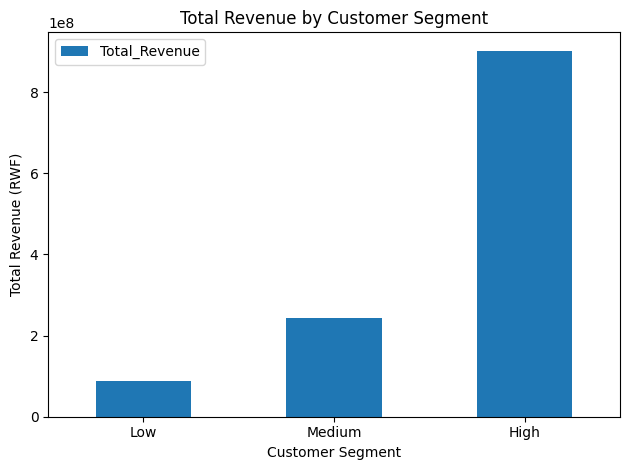

In [8]:
import matplotlib.pyplot as plt

segment_summary.plot(
    x="Revenue_Segment",
    y="Total_Revenue",
    kind="bar"
)

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (RWF)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
products = pd.read_excel(file_path, sheet_name="DimProduct")

sales_product = sales.merge(
    products[["ProductID", "ProductName", "Category", "UnitCost"]],
    on="ProductID",
    how="left"
)

sales_product["TotalCost"] = (
    sales_product["Quantity"] *
    sales_product["UnitCost"]
)

sales_product["GrossProfit"] = (
    sales_product["NetSales"] -
    sales_product["TotalCost"]
)

In [23]:
store_kpi = sales_product.groupby("StoreID").agg(
    Total_Net_Sales=("NetSales", "sum"),
    Number_of_Transactions=("TransactionID", "nunique"),
    Units_Sold=("Quantity", "sum"),
    Gross_Profit=("GrossProfit", "sum")
).reset_index()

store_kpi["Average_Transaction_Value"] = (
    store_kpi["Total_Net_Sales"] /
    store_kpi["Number_of_Transactions"]
)

store_kpi["Profit_Margin"] = (
    store_kpi["Gross_Profit"] /
    store_kpi["Total_Net_Sales"] * 100
)

In [25]:
stores = pd.read_excel(file_path, sheet_name="DimStore")

store_kpi = store_kpi.merge(
    stores[["StoreID", "StoreName"]],
    on="StoreID",
    how="left"
)

store_kpi = store_kpi[
    [
        "StoreID",
        "StoreName",
        "Total_Net_Sales",
        "Number_of_Transactions",
        "Units_Sold",
        "Average_Transaction_Value",
        "Gross_Profit",
        "Profit_Margin"
    ]
]

store_kpi.sort_values(
    "Total_Net_Sales",
    ascending=False
)

,StoreID,StoreName,Total_Net_Sales,Number_of_Transactions,Units_Sold,Average_Transaction_Value,Gross_Profit,Profit_Margin
0,1,Kigali City Centre,2.444683e+08,4919,12800,49698.786406,66405280.33,27.163142
1,2,Kimironko,1.850774e+08,3976,10058,46548.635817,49545876.01,26.770358
2,3,Kicukiro Mall,1.591844e+08,3229,8418,49298.368356,42831581.42,26.906891
3,4,Musanze Central,1.389773e+08,2739,7174,50740.173837,37267336.14,26.815405
6,7,Nyagatare Plaza,1.325171e+08,2622,6856,50540.467121,35185954.79,26.552010
4,5,Rubavu Centre,1.296607e+08,2421,6293,53556.691132,32994199.23,25.446559
7,8,Muhanga Hub,1.242324e+08,2551,6639,48699.472846,33454905.23,26.929301
5,6,Huye Market,1.202503e+08,2543,6668,47286.802957,31806189.92,26.449979


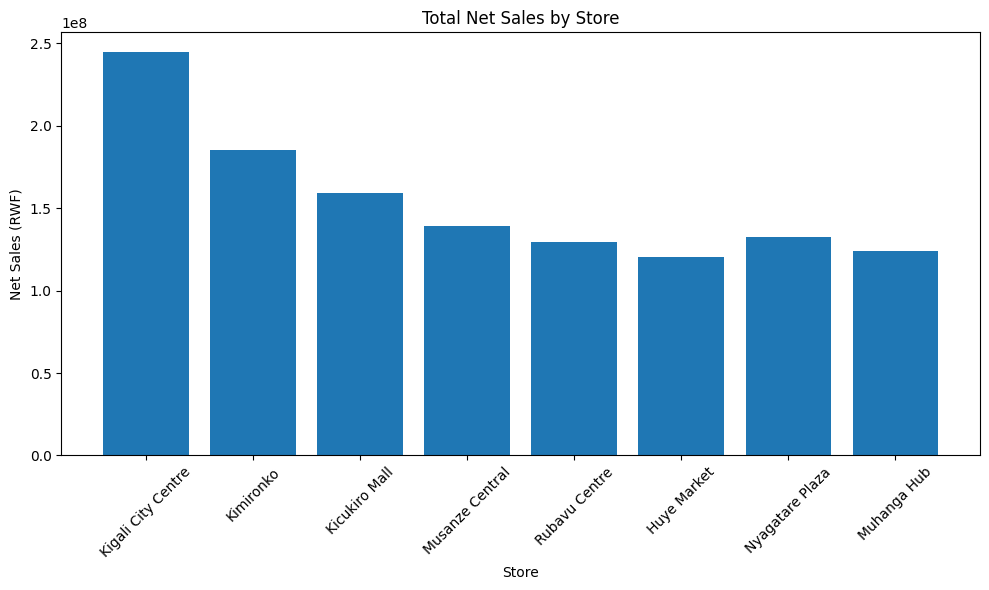

In [26]:
plt.figure(figsize=(10,6))

plt.bar(
    store_kpi["StoreName"],
    store_kpi["Total_Net_Sales"]
)

plt.title("Total Net Sales by Store")
plt.xlabel("Store")
plt.ylabel("Net Sales (RWF)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

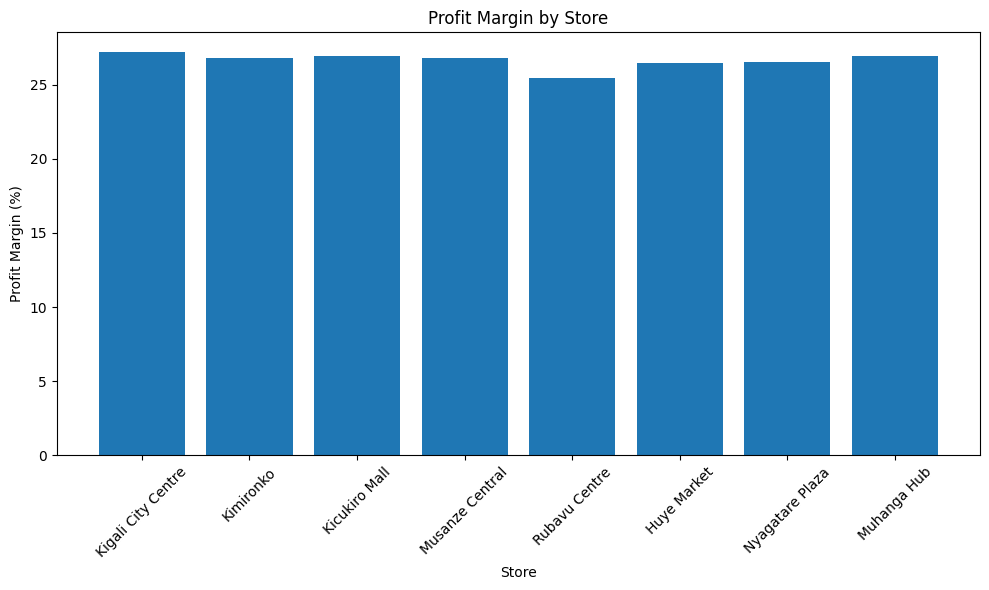

In [27]:
plt.figure(figsize=(10,6))

plt.bar(
    store_kpi["StoreName"],
    store_kpi["Profit_Margin"]
)

plt.title("Profit Margin by Store")
plt.xlabel("Store")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 Interpretation for Question 1



The store-level analysis shows differences in sales volume, transaction activity, units sold, gross profit, and profit margin across the eight stores. Kigali City Centre recorded the highest total net sales of approximately RWF 244.47 million and also recorded the highest number of transactions and units sold. Huye Market recorded the lowest total net sales at approximately RWF 120.25 million. Profit margins were relatively close across the stores, ranging from approximately 25.45% to 27.16%. This suggests that differences in total sales are associated more strongly with transaction and sales volume than with large differences in profit margin.

Management interpretation

Management should monitor store performance using several KPIs rather than relying on sales alone. Stores with lower sales may require investigation of customer traffic, product availability, product mix, pricing, promotions, and local market conditions.

Correlation vs causation

The results describe differences and associations between store KPIs. They do not prove that a particular factor, such as customer traffic or promotions, caused the differences because those factors were not independently tested in this analysis.

QUESTION 2: Monthly Store Performance vs Sales Targets

In [28]:
sales["Month"] = sales["TransactionDate"].dt.to_period("M").astype(str)

monthly_store_sales = sales.groupby(
    ["Month", "StoreID"]
).agg(
    Monthly_Net_Sales=("NetSales", "sum")
).reset_index()

In [30]:
targets = pd.read_excel(file_path, sheet_name="Targets")
targets["Month"] = pd.to_datetime(
    targets["Month"]
).dt.to_period("M").astype(str)

In [31]:
monthly_target = monthly_store_sales.merge(
    targets,
    on=["Month", "StoreID"],
    how="left"
)

In [32]:
monthly_target["Target_Achievement"] = (
    monthly_target["Monthly_Net_Sales"] /
    monthly_target["SalesTarget"] * 100
)

monthly_target.head()

,Month,StoreID,Monthly_Net_Sales,SalesTarget,Target_Achievement
0,2025-01,1,23563586.51,17464775,134.920642
1,2025-01,2,13072065.77,18074483,72.323318
2,2025-01,3,14430248.64,23763965,60.723236
3,2025-01,4,11546387.91,22645508,50.987542
4,2025-01,5,8305590.91,19988105,41.552668


In [33]:
above_target = monthly_target[
    monthly_target["Target_Achievement"] > 100
]

above_target.sort_values(
    "Target_Achievement",
    ascending=False
).head(20)

,Month,StoreID,Monthly_Net_Sales,SalesTarget,Target_Achievement
0,2025-01,1,23563586.51,17464775,134.920642
88,2025-12,1,25191541.40,19770125,127.422267
64,2025-09,1,24156153.77,19141393,126.198515
40,2025-06,1,22893771.81,18512661,123.665484
48,2025-07,1,22945313.99,18722239,122.556463
80,2025-11,1,23476911.75,19560548,120.021749
56,2025-08,1,21639216.65,18931816,114.300797
16,2025-03,1,18906529.42,17883929,105.717985
17,2025-03,2,18715576.53,18508271,101.120070


In [34]:
monthly_target.loc[
    monthly_target["Target_Achievement"].idxmax()
]

,0
Month,2025-01
StoreID,1
Monthly_Net_Sales,23563586.51
SalesTarget,17464775
Target_Achievement,134.920642


In [35]:
monthly_target.loc[
    monthly_target["Target_Achievement"].idxmin()
]

,35
Month,2025-05
StoreID,4
Monthly_Net_Sales,7228486.57
SalesTarget,23732493
Target_Achievement,30.458185


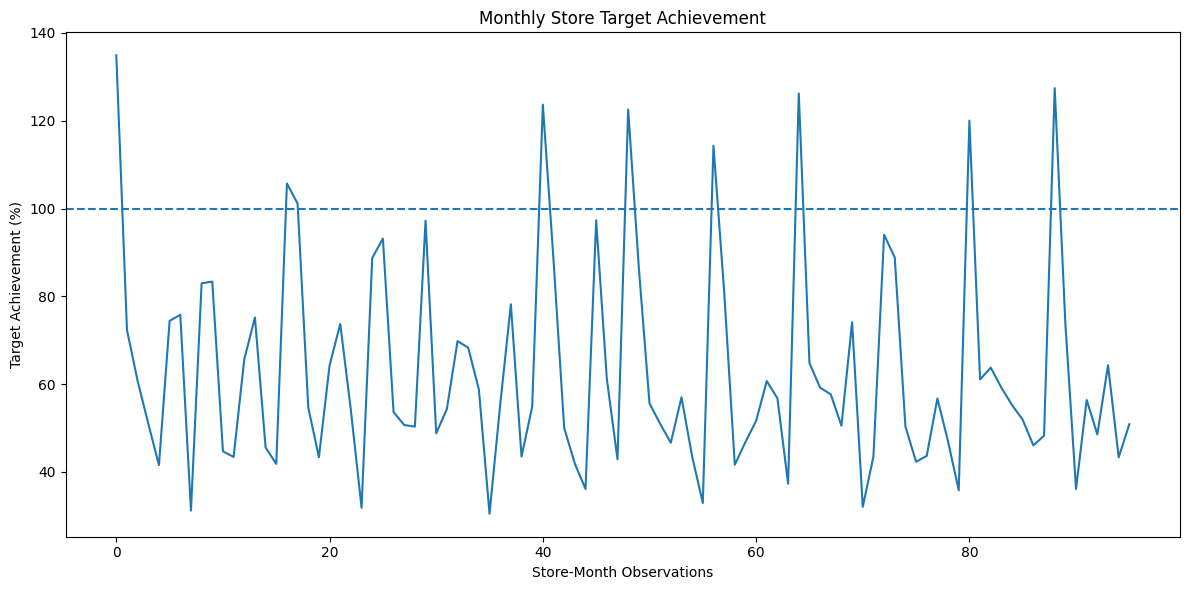

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_target["Target_Achievement"]
)

plt.axhline(
    100,
    linestyle="--"
)

plt.title("Monthly Store Target Achievement")
plt.xlabel("Store-Month Observations")
plt.ylabel("Target Achievement (%)")
plt.tight_layout()
plt.show()

Interpretation

The monthly target analysis shows that store performance varies considerably across months. Kigali City Centre recorded a target achievement of approximately 134.92% in January, meaning that its actual sales were above the monthly target. In contrast, Musanze Central recorded approximately 30.46% of its target in May. These differences indicate that some store-month combinations substantially exceeded targets while others were below expectations.

Possible areas to investigate
Customer traffic
Product availability
Promotions
Discounts
Seasonal demand
Local market conditions
Store operations

Important: These are possible explanations to investigate. The dataset does not by itself prove that any one of them caused the result.

CASE STUDY TWO — CUSTOMER VALUE
QUESTION 3: Customer Value Analysis

In [37]:
customer_value = sales.groupby("CustomerID").agg(
    Total_Revenue=("NetSales", "sum"),
    Number_of_Transactions=("TransactionID", "nunique"),
    First_Purchase=("TransactionDate", "min"),
    Last_Purchase=("TransactionDate", "max")
).reset_index()

In [38]:
customer_value["Lifetime_Days"] = (
    customer_value["Last_Purchase"] -
    customer_value["First_Purchase"]
).dt.days

customer_value["Lifetime_Days"] = (
    customer_value["Lifetime_Days"].replace(0, 1)
)

In [39]:
customer_value["Average_Order_Value"] = (
    customer_value["Total_Revenue"] /
    customer_value["Number_of_Transactions"]
)

In [40]:
customer_value["Revenue_per_Day"] = (
    customer_value["Total_Revenue"] /
    customer_value["Lifetime_Days"]
)

In [41]:
customer_value["Revenue_Segment"] = pd.qcut(
    customer_value["Total_Revenue"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

In [42]:
segment_summary = customer_value.groupby(
    "Revenue_Segment",
    observed=True
).agg(
    Customers=("CustomerID", "count"),
    Total_Revenue=("Total_Revenue", "sum"),
    Average_Revenue=("Total_Revenue", "mean"),
    Average_Transactions=("Number_of_Transactions", "mean"),
    Average_Order_Value=("Average_Order_Value", "mean")
).reset_index()

segment_summary

,Revenue_Segment,Customers,Total_Revenue,Average_Revenue,Average_Transactions,Average_Order_Value
0,Low,1658,8.879409e+07,53554.939903,3.454765,16687.631961
1,Medium,1658,2.430459e+08,146589.779831,5.286490,31086.815736
2,High,1659,9.025281e+08,544019.335594,6.333333,97615.564885


In [43]:
frequency_median = customer_value[
    "Number_of_Transactions"
].median()

high_revenue_low_frequency = customer_value[
    (customer_value["Revenue_Segment"] == "High") &
    (customer_value["Number_of_Transactions"] < frequency_median)
].sort_values(
    "Total_Revenue",
    ascending=False
)

high_revenue_low_frequency.head(20)

,CustomerID,Total_Revenue,Number_of_Transactions,First_Purchase,Last_Purchase,Lifetime_Days,Average_Order_Value,Revenue_per_Day,Revenue_Segment
3557,13580,2792389.96,4,2025-03-04,2025-12-15,286,698097.490000,9763.601259,High
2275,12290,2429376.00,3,2025-03-10,2025-07-21,133,809792.000000,18265.984962,High
4658,14683,2274497.72,4,2025-02-17,2025-10-14,239,568624.430000,9516.726862,High
1047,11055,2135149.92,4,2025-03-24,2025-12-17,268,533787.480000,7966.977313,High
4927,14953,1999433.20,4,2025-02-07,2025-09-20,225,499858.300000,8886.369778,High
4053,14076,1983444.50,3,2025-03-02,2025-09-20,202,661148.166667,9819.032178,High
869,10872,1978705.04,4,2025-07-04,2025-12-08,157,494676.260000,12603.216815,High
3393,13416,1901821.60,4,2025-01-26,2025-12-31,339,475455.400000,5610.093215,High
365,10367,1876778.65,3,2025-03-01,2025-12-15,289,625592.883333,6494.043772,High
186,10187,1829426.00,3,2025-06-16,2025-12-03,170,609808.666667,10761.329412,High


Interpretation

The customer value analysis divides customers into Low, Medium, and High revenue segments. The High revenue segment contributes substantially more revenue and has a higher average order value than the other segments. The analysis also identifies customers who generate relatively high revenue despite having lower transaction frequency. These customers may generate their value through larger purchases rather than frequent purchases.

QUESTION 4: RFM Analysis

In [44]:
reference_date = (
    sales["TransactionDate"].max()
    + pd.Timedelta(days=1)
)

print(reference_date)

2026-01-01 00:00:00


In [45]:
rfm = sales.groupby("CustomerID").agg(
    Last_Purchase=("TransactionDate", "max"),
    Frequency=("TransactionID", "nunique"),
    Monetary=("NetSales", "sum")
).reset_index()

rfm["Recency"] = (
    reference_date - rfm["Last_Purchase"]
).dt.days

In [46]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5,4,3,2,1]
).astype(int)

In [47]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [48]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
).astype(int)

In [49]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,CustomerID,Last_Purchase,Frequency,Monetary,Recency,R_Score,F_Score,M_Score,RFM_Score
0,10001,2025-07-09,4,227250.84,176,1,2,4,124
1,10002,2025-11-17,5,104242.04,45,3,3,2,332
2,10003,2025-08-22,1,33632.85,132,1,1,1,111
3,10004,2025-12-25,6,231642.98,7,5,4,4,544
4,10005,2025-10-13,4,141817.25,80,2,2,3,223


In [51]:
def rfm_segment(row):

    R = row["R_Score"]
    F = row["F_Score"]
    M = row["M_Score"]

    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"

    elif F >= 4 and M >= 3 and R >= 3:
        return "Loyal"

    elif R <= 2 and F >= 3 and M >= 3:
        return "At Risk"

    elif R <= 2 and F <= 2 and M <= 2:
        return "Lost"

    else:
        return "Other"


rfm["Segment"] = rfm.apply(
    rfm_segment,
    axis=1
)

rfm["Segment"].value_counts()

,count
Segment,
Other,2271
Lost,776
Champions,676
At Risk,674
Loyal,578


In [53]:
high_value_at_risk = rfm[
    (rfm["Segment"] == "At Risk") &
    (rfm["M_Score"] >= 4)
].sort_values(
    "Monetary",
    ascending=False
)

high_value_at_risk.head(20)

,CustomerID,Last_Purchase,Frequency,Monetary,Recency,R_Score,F_Score,M_Score,RFM_Score,Segment
3918,13941,2025-10-10,9,3256940.13,83,2,5,5,255,At Risk
4468,14492,2025-10-08,9,3178281.98,85,2,5,5,255,At Risk
4273,14296,2025-10-17,7,2400658.70,76,2,5,5,255,At Risk
1263,11272,2025-07-31,5,2374599.00,154,1,3,5,135,At Risk
4658,14683,2025-10-14,4,2274497.72,79,2,3,5,235,At Risk
4927,14953,2025-09-20,4,1999433.20,103,2,3,5,235,At Risk
1604,11618,2025-10-16,7,1986836.59,77,2,5,5,255,At Risk
2080,12095,2025-07-22,5,1967496.36,163,1,3,5,135,At Risk
1328,11339,2025-09-16,6,1960473.38,107,2,4,5,245,At Risk
1326,11336,2025-09-24,8,1913796.92,99,2,5,5,255,At Risk


In this dataset, the analysis identifies approximately 452 high-value at-risk customers under this scoring rule.

Interpretation

RFM analysis helps management understand customer behaviour using recency, frequency, and monetary value. Customers classified as Champions have recent purchases, relatively high transaction frequency, and high monetary value. At-risk customers have relatively poor recency but may still have high frequency or monetary value. These customers deserve attention because their recent purchasing activity is lower than desired.

Recommendation

Management can:

Send personalized reminders.
Offer relevant promotions.
Introduce loyalty rewards.
Contact valuable inactive customers.
Monitor changes in customer behaviour.

CASE STUDY THREE — PRODUCT AND CATEGORY
QUESTION 5: Product and Category Performance

In [54]:
product_sales = sales.merge(
    products[[
        "ProductID",
        "ProductName",
        "Category",
        "UnitCost"
    ]],
    on="ProductID",
    how="left"
)

In [55]:
product_sales["Total_Cost"] = (
    product_sales["Quantity"] *
    product_sales["UnitCost"]
)

product_sales["Gross_Profit"] = (
    product_sales["NetSales"] -
    product_sales["Total_Cost"]
)

In [56]:
product_kpi = product_sales.groupby(
    ["ProductID", "ProductName", "Category"]
).agg(
    Product_Revenue=("NetSales", "sum"),
    Units_Sold=("Quantity", "sum"),
    Total_Cost=("Total_Cost", "sum"),
    Gross_Profit=("Gross_Profit", "sum")
).reset_index()

product_kpi["Average_Unit_Price"] = (
    product_kpi["Product_Revenue"] /
    product_kpi["Units_Sold"]
)

product_kpi["Profit_Margin"] = (
    product_kpi["Gross_Profit"] /
    product_kpi["Product_Revenue"] * 100
)

product_kpi.head()

,ProductID,ProductName,Category,Product_Revenue,Units_Sold,Total_Cost,Gross_Profit,Average_Unit_Price,Profit_Margin
0,1,Rice 5kg,Food & Beverage,7306193.71,1166,5596800,1709393.71,6266.032341,23.396501
1,2,Cooking Oil 1L,Food & Beverage,3501889.17,1118,2683200,818689.17,3132.280116,23.378500
2,3,Milk 1L,Food & Beverage,1855155.64,1068,1388400,466755.64,1737.037116,25.159918
3,4,Sugar 1kg,Food & Beverage,1688367.49,1017,1271250,417117.49,1660.145025,24.705373
4,5,Biscuits Pack,Food & Beverage,1385822.20,1184,947200,438622.20,1170.457939,31.650684


In [57]:
category_kpi = product_kpi.groupby(
    "Category"
).agg(
    Product_Revenue=("Product_Revenue", "sum"),
    Units_Sold=("Units_Sold", "sum"),
    Gross_Profit=("Gross_Profit", "sum")
).reset_index()

category_kpi["Profit_Margin"] = (
    category_kpi["Gross_Profit"] /
    category_kpi["Product_Revenue"] * 100
)

category_kpi.sort_values(
    "Product_Revenue",
    ascending=False
)

,Category,Product_Revenue,Units_Sold,Gross_Profit,Profit_Margin
1,Electronics,6.488274e+08,10762,1.388243e+08,21.396180
3,Home & Kitchen,2.515526e+08,11075,8.504490e+07,33.808000
0,Agriculture,1.129778e+08,10401,3.551612e+07,31.436363
5,Personal Care,9.973960e+07,11047,3.257660e+07,32.661650
4,Office & Stationery,9.129694e+07,10858,2.979444e+07,32.634653
2,Food & Beverage,2.997370e+07,10763,7.734997e+06,25.805950


In [58]:
low_margin_products = product_kpi.sort_values(
    "Profit_Margin"
).head(10)

low_margin_products[
    [
        "ProductName",
        "Category",
        "Product_Revenue",
        "Gross_Profit",
        "Profit_Margin"
    ]
]

,ProductName,Category,Product_Revenue,Gross_Profit,Profit_Margin
19,Smartphone Midrange,Electronics,3.297730e+08,57688039.24,17.493255
18,Smartphone Entry,Electronics,1.857773e+08,35267297.96,18.983642
1,Cooking Oil 1L,Food & Beverage,3.501889e+06,818689.17,23.378500
0,Rice 5kg,Food & Beverage,7.306194e+06,1709393.71,23.396501
9,Flour 2kg,Food & Beverage,2.596229e+06,618329.21,23.816434
3,Sugar 1kg,Food & Beverage,1.688367e+06,417117.49,24.705373
2,Milk 1L,Food & Beverage,1.855156e+06,466755.64,25.159918
51,Bean Seed 2kg,Agriculture,8.180000e+06,2089499.97,25.544010
6,Tea 100 Bags,Food & Beverage,4.059584e+06,1065284.42,26.241219
50,Maize Seed 2kg,Agriculture,9.679979e+06,2542979.28,26.270503


The analysis shows, for example, that Smartphone Midrange has a relatively low margin of approximately 17.49%.

Interpretation

Electronics generates the highest revenue among the categories, but its profit margin is lower than several other categories. This means that high revenue does not necessarily mean high profitability. Management should therefore consider both revenue and margin when evaluating products and categories.

QUESTION 6: Product Trends

In [59]:
product_sales["Month"] = (
    product_sales["TransactionDate"]
    .dt.to_period("M")
    .astype(str)
)

monthly_category = product_sales.groupby(
    ["Month", "Category"]
)["NetSales"].sum().reset_index()

monthly_category.head()

,Month,Category,NetSales
0,2025-01,Agriculture,9771036.24
1,2025-01,Electronics,52506778.52
2,2025-01,Food & Beverage,2701453.46
3,2025-01,Home & Kitchen,21976197.70
4,2025-01,Office & Stationery,8011710.71


In [60]:
monthly_category["Growth_Rate"] = (
    monthly_category
    .groupby("Category")["NetSales"]
    .pct_change() * 100
)

monthly_category.head(20)

,Month,Category,NetSales,Growth_Rate
0,2025-01,Agriculture,9771036.24,NaN
1,2025-01,Electronics,52506778.52,NaN
2,2025-01,Food & Beverage,2701453.46,NaN
3,2025-01,Home & Kitchen,21976197.70,NaN
4,2025-01,Office & Stationery,8011710.71,NaN
5,2025-01,Personal Care,8758171.58,NaN
6,2025-02,Agriculture,7892365.15,-19.226938
7,2025-02,Electronics,54785803.95,4.340440
8,2025-02,Food & Beverage,2180708.82,-19.276462
9,2025-02,Home & Kitchen,17258419.16,-21.467674


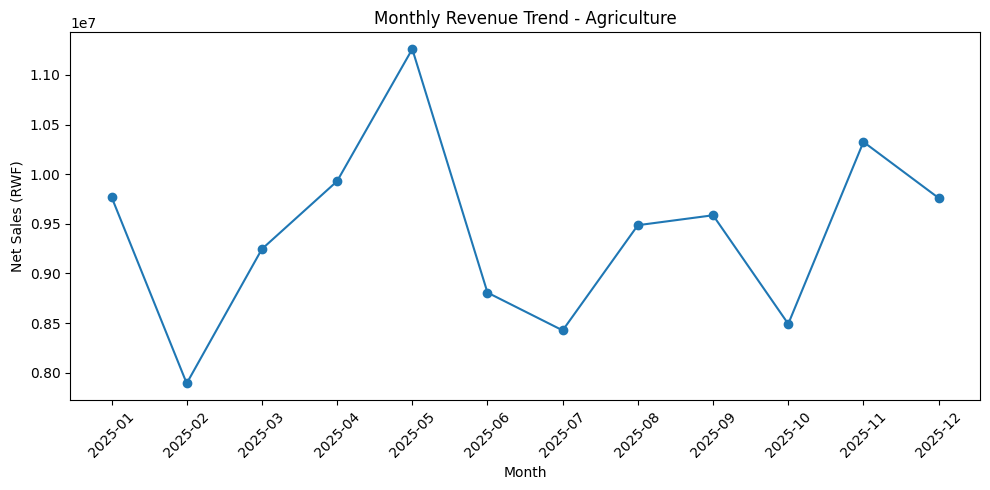

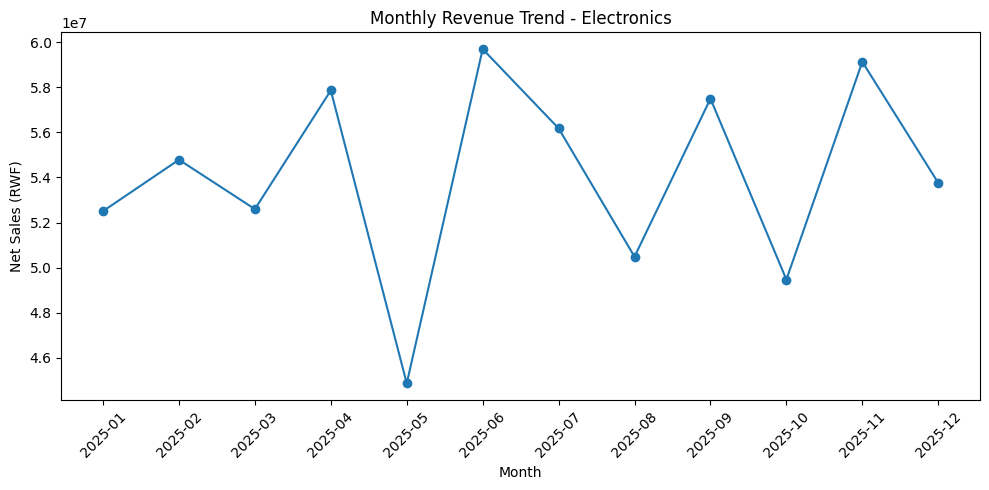

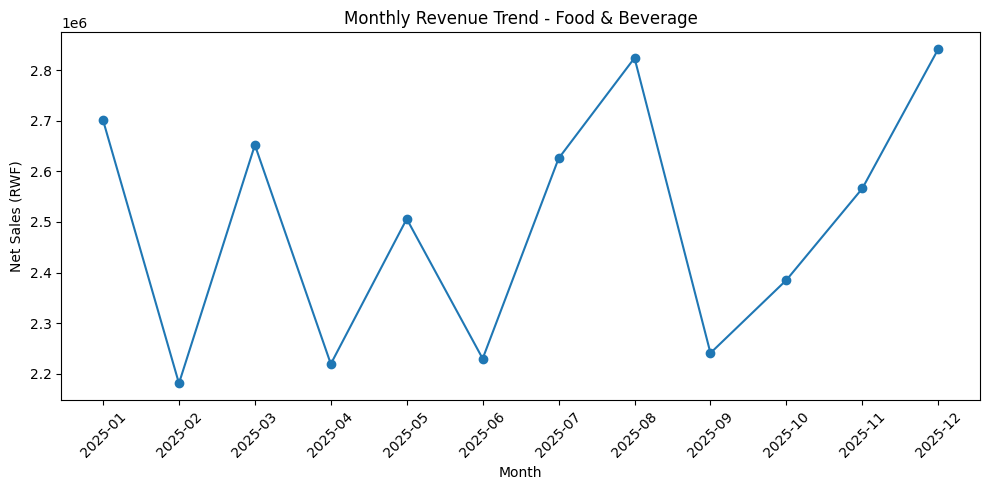

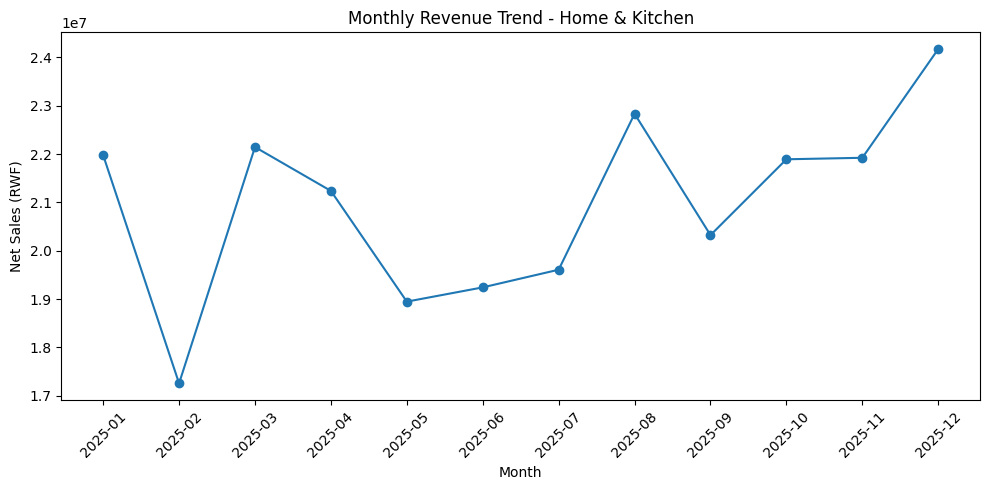

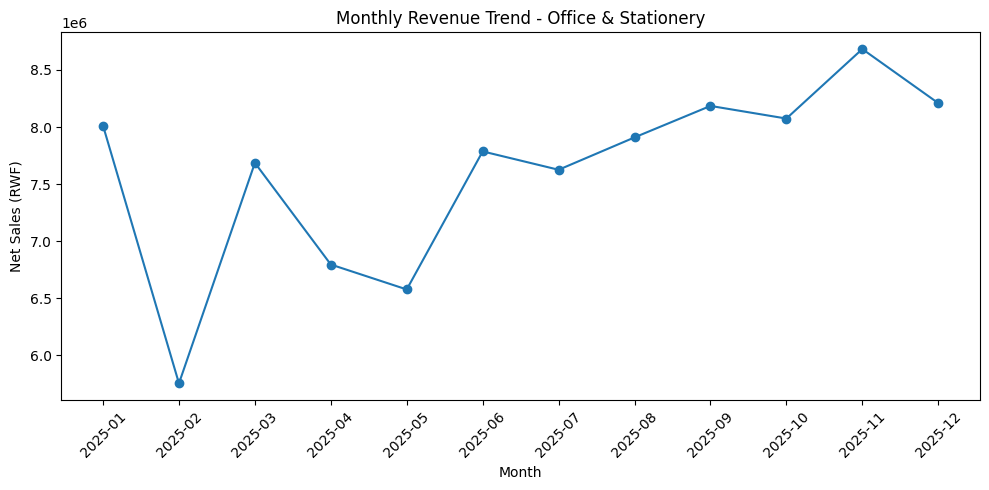

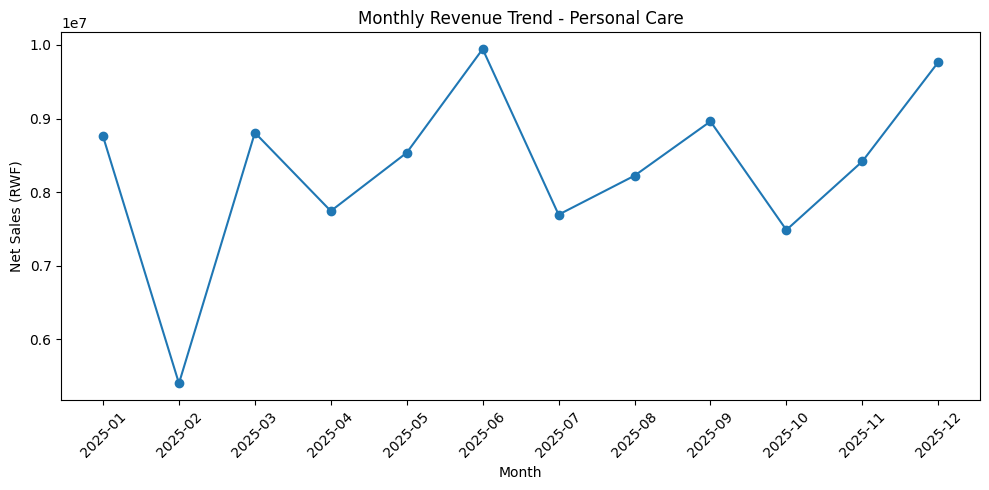

In [61]:
categories = monthly_category["Category"].unique()

for category in categories:

    data = monthly_category[
        monthly_category["Category"] == category
    ]

    plt.figure(figsize=(10,5))

    plt.plot(
        data["Month"],
        data["NetSales"],
        marker="o"
    )

    plt.title(
        f"Monthly Revenue Trend - {category}"
    )

    plt.xlabel("Month")
    plt.ylabel("Net Sales (RWF)")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

Interpretation

The monthly trend analysis shows that category revenue changes from month to month. Some categories experience increases while others decline in particular months. These changes may reflect seasonal demand, product availability, promotions, pricing, or customer purchasing patterns. However, the trend analysis alone does not establish which factor caused the changes.

CASE STUDY FOUR — DISCOUNT ANALYSIS
QUESTION 7: Discount Impact

In [62]:
discount_analysis = sales.merge(
    products[["ProductID", "UnitCost"]],
    on="ProductID",
    how="left"
)

discount_analysis["Total_Cost"] = (
    discount_analysis["Quantity"] *
    discount_analysis["UnitCost"]
)

discount_analysis["Gross_Profit"] = (
    discount_analysis["NetSales"] -
    discount_analysis["Total_Cost"]
)

In [63]:
discount_summary = discount_analysis.groupby(
    "StoreID"
).agg(
    Gross_Sales=("GrossSales", "sum"),
    Net_Sales=("NetSales", "sum"),
    Discount_Amount=("DiscountAmount", "sum"),
    Gross_Profit=("Gross_Profit", "sum")
).reset_index()

discount_summary["Discount_Rate"] = (
    discount_summary["Discount_Amount"] /
    discount_summary["Gross_Sales"] * 100
)

discount_summary["Profit_Margin"] = (
    discount_summary["Gross_Profit"] /
    discount_summary["Net_Sales"] * 100
)

discount_summary

,StoreID,Gross_Sales,Net_Sales,Discount_Amount,Gross_Profit,Discount_Rate,Profit_Margin
0,1,255450126,2.444683e+08,10981795.67,66405280.33,4.298998,27.163142
1,2,192600272,1.850774e+08,7522895.99,49545876.01,3.905963,26.770358
2,3,165589969,1.591844e+08,6405537.58,42831581.42,3.868313,26.906891
3,4,145136337,1.389773e+08,6159000.86,37267336.14,4.243597,26.815405
4,5,136065225,1.296607e+08,6404475.77,32994199.23,4.706916,25.446559
5,6,125879146,1.202503e+08,5628806.08,31806189.92,4.471595,26.449979
6,7,138032675,1.325171e+08,5515570.21,35185954.79,3.995844,26.552010
7,8,129943184,1.242324e+08,5710828.77,33454905.23,4.394866,26.929301


In [64]:
correlation = discount_summary[
    ["Discount_Rate", "Profit_Margin"]
].corr()

correlation

,Discount_Rate,Profit_Margin
Discount_Rate,1.000000,-0.594632
Profit_Margin,-0.594632,1.000000


In [65]:
sales[
    ["DiscountPct", "NetSales"]
].corr()

,DiscountPct,NetSales
DiscountPct,1.000000,-0.015371
NetSales,-0.015371,1.000000


Interpretation

The discount analysis compares discount levels with sales and profit margin. The purpose is to determine whether higher discounting is associated with differences in profitability. The analysis should be interpreted as an association rather than proof of causation.

An important finding from the store-level results is that profit margins are relatively close across stores even though sales levels differ substantially.



The analysis examines whether discount levels are associated with differences in profit margin. The results do not establish a causal relationship because other factors may also influence profitability

QUESTION 8: Discount Strategy

In [66]:
high_discount = discount_summary.sort_values(
    "Discount_Rate",
    ascending=False
)

high_discount

,StoreID,Gross_Sales,Net_Sales,Discount_Amount,Gross_Profit,Discount_Rate,Profit_Margin
4,5,136065225,1.296607e+08,6404475.77,32994199.23,4.706916,25.446559
5,6,125879146,1.202503e+08,5628806.08,31806189.92,4.471595,26.449979
7,8,129943184,1.242324e+08,5710828.77,33454905.23,4.394866,26.929301
0,1,255450126,2.444683e+08,10981795.67,66405280.33,4.298998,27.163142
3,4,145136337,1.389773e+08,6159000.86,37267336.14,4.243597,26.815405
6,7,138032675,1.325171e+08,5515570.21,35185954.79,3.995844,26.552010
1,2,192600272,1.850774e+08,7522895.99,49545876.01,3.905963,26.770358
2,3,165589969,1.591844e+08,6405537.58,42831581.42,3.868313,26.906891


In [67]:
discount_analysis["Discount_Band"] = pd.cut(
    discount_analysis["DiscountPct"],
    bins=[-1, 5, 10, 20, 100],
    labels=[
        "Low Discount",
        "Medium Discount",
        "High Discount",
        "Very High Discount"
    ]
)

In [68]:
discount_band = discount_analysis.groupby(
    "Discount_Band",
    observed=True
).agg(
    Gross_Sales=("GrossSales", "sum"),
    Net_Sales=("NetSales", "sum"),
    Gross_Profit=("Gross_Profit", "sum")
).reset_index()

discount_band["Profit_Margin"] = (
    discount_band["Gross_Profit"] /
    discount_band["Net_Sales"] * 100
)

discount_band

,Discount_Band,Gross_Sales,Net_Sales,Gross_Profit,Profit_Margin
0,Low Discount,1285456435,1.231360e+09,3.287327e+08,26.696722


Management recommendation

Management should avoid applying the same discount level to all products and stores. Discount decisions should consider product margin, category performance, store performance, and customer response. High discounts should be monitored carefully, especially for products that already have low profit margins.

CASE STUDY FIVE — STORE COMPARISON
QUESTION 9: Store Comparison and Ranking

In [70]:
store_comparison = store_kpi.merge(
    stores[["StoreID", "StoreName"]],
    on="StoreID",
    how="left",
    suffixes=("", "_new")
)

store_comparison = store_comparison[
    [
        "StoreID",
        "StoreName",
        "Total_Net_Sales",
        "Number_of_Transactions",
        "Average_Transaction_Value",
        "Gross_Profit",
        "Profit_Margin"
    ]
]

store_comparison

,StoreID,StoreName,Total_Net_Sales,Number_of_Transactions,Average_Transaction_Value,Gross_Profit,Profit_Margin
0,1,Kigali City Centre,2.444683e+08,4919,49698.786406,66405280.33,27.163142
1,2,Kimironko,1.850774e+08,3976,46548.635817,49545876.01,26.770358
2,3,Kicukiro Mall,1.591844e+08,3229,49298.368356,42831581.42,26.906891
3,4,Musanze Central,1.389773e+08,2739,50740.173837,37267336.14,26.815405
4,5,Rubavu Centre,1.296607e+08,2421,53556.691132,32994199.23,25.446559
5,6,Huye Market,1.202503e+08,2543,47286.802957,31806189.92,26.449979
6,7,Nyagatare Plaza,1.325171e+08,2622,50540.467121,35185954.79,26.552010
7,8,Muhanga Hub,1.242324e+08,2551,48699.472846,33454905.23,26.929301


In [71]:
store_comparison.sort_values(
    "Total_Net_Sales",
    ascending=False
)

,StoreID,StoreName,Total_Net_Sales,Number_of_Transactions,Average_Transaction_Value,Gross_Profit,Profit_Margin
0,1,Kigali City Centre,2.444683e+08,4919,49698.786406,66405280.33,27.163142
1,2,Kimironko,1.850774e+08,3976,46548.635817,49545876.01,26.770358
2,3,Kicukiro Mall,1.591844e+08,3229,49298.368356,42831581.42,26.906891
3,4,Musanze Central,1.389773e+08,2739,50740.173837,37267336.14,26.815405
6,7,Nyagatare Plaza,1.325171e+08,2622,50540.467121,35185954.79,26.552010
4,5,Rubavu Centre,1.296607e+08,2421,53556.691132,32994199.23,25.446559
7,8,Muhanga Hub,1.242324e+08,2551,48699.472846,33454905.23,26.929301
5,6,Huye Market,1.202503e+08,2543,47286.802957,31806189.92,26.449979


In [72]:
store_comparison.sort_values(
    "Profit_Margin",
    ascending=False
)

,StoreID,StoreName,Total_Net_Sales,Number_of_Transactions,Average_Transaction_Value,Gross_Profit,Profit_Margin
0,1,Kigali City Centre,2.444683e+08,4919,49698.786406,66405280.33,27.163142
7,8,Muhanga Hub,1.242324e+08,2551,48699.472846,33454905.23,26.929301
2,3,Kicukiro Mall,1.591844e+08,3229,49298.368356,42831581.42,26.906891
3,4,Musanze Central,1.389773e+08,2739,50740.173837,37267336.14,26.815405
1,2,Kimironko,1.850774e+08,3976,46548.635817,49545876.01,26.770358
6,7,Nyagatare Plaza,1.325171e+08,2622,50540.467121,35185954.79,26.552010
5,6,Huye Market,1.202503e+08,2543,47286.802957,31806189.92,26.449979
4,5,Rubavu Centre,1.296607e+08,2421,53556.691132,32994199.23,25.446559


In [73]:
store_comparison.sort_values(
    "Average_Transaction_Value",
    ascending=False
)

,StoreID,StoreName,Total_Net_Sales,Number_of_Transactions,Average_Transaction_Value,Gross_Profit,Profit_Margin
4,5,Rubavu Centre,1.296607e+08,2421,53556.691132,32994199.23,25.446559
3,4,Musanze Central,1.389773e+08,2739,50740.173837,37267336.14,26.815405
6,7,Nyagatare Plaza,1.325171e+08,2622,50540.467121,35185954.79,26.552010
0,1,Kigali City Centre,2.444683e+08,4919,49698.786406,66405280.33,27.163142
2,3,Kicukiro Mall,1.591844e+08,3229,49298.368356,42831581.42,26.906891
7,8,Muhanga Hub,1.242324e+08,2551,48699.472846,33454905.23,26.929301
5,6,Huye Market,1.202503e+08,2543,47286.802957,31806189.92,26.449979
1,2,Kimironko,1.850774e+08,3976,46548.635817,49545876.01,26.770358


Important interpretation

Do not rely on only one KPI.

For example:

Kigali City Centre has the highest net sales, transactions, units sold, and gross profit. However, store comparison should consider several KPIs because a store can have high sales but a different profit margin or average transaction value.

This is important because high sales and high profitability are not automatically the same thing.

QUESTION 10: Sales Forecasting

In [74]:
monthly_sales = sales.groupby(
    sales["TransactionDate"].dt.to_period("M")
)["NetSales"].sum().reset_index()

monthly_sales["Month"] = (
    monthly_sales["TransactionDate"]
    .astype(str)
)

monthly_sales

,TransactionDate,NetSales,Month
0,2025-01,1.037253e+08,2025-01
1,2025-02,9.327233e+07,2025-02
2,2025-03,1.031316e+08,2025-03
3,2025-04,1.057824e+08,2025-04
4,2025-05,9.269844e+07,2025-05
5,2025-06,1.077024e+08,2025-06
6,2025-07,1.021554e+08,2025-07
7,2025-08,1.017619e+08,2025-08
8,2025-09,1.067885e+08,2025-09
9,2025-10,9.780096e+07,2025-10


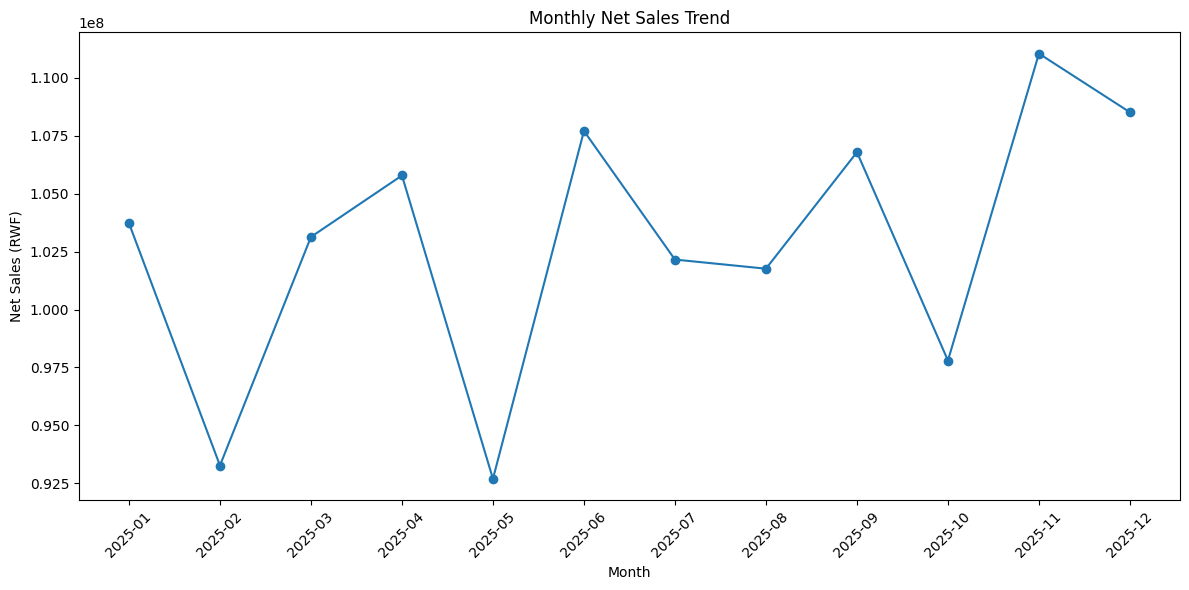

In [75]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["NetSales"],
    marker="o"
)

plt.title("Monthly Net Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales (RWF)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [76]:
monthly_sales["3_Month_Moving_Average"] = (
    monthly_sales["NetSales"]
    .rolling(3)
    .mean()
)

monthly_sales

,TransactionDate,NetSales,Month,3_Month_Moving_Average
0,2025-01,1.037253e+08,2025-01,NaN
1,2025-02,9.327233e+07,2025-02,NaN
2,2025-03,1.031316e+08,2025-03,1.000431e+08
3,2025-04,1.057824e+08,2025-04,1.007288e+08
4,2025-05,9.269844e+07,2025-05,1.005375e+08
5,2025-06,1.077024e+08,2025-06,1.020611e+08
6,2025-07,1.021554e+08,2025-07,1.008521e+08
7,2025-08,1.017619e+08,2025-08,1.038732e+08
8,2025-09,1.067885e+08,2025-09,1.035686e+08
9,2025-10,9.780096e+07,2025-10,1.021171e+08


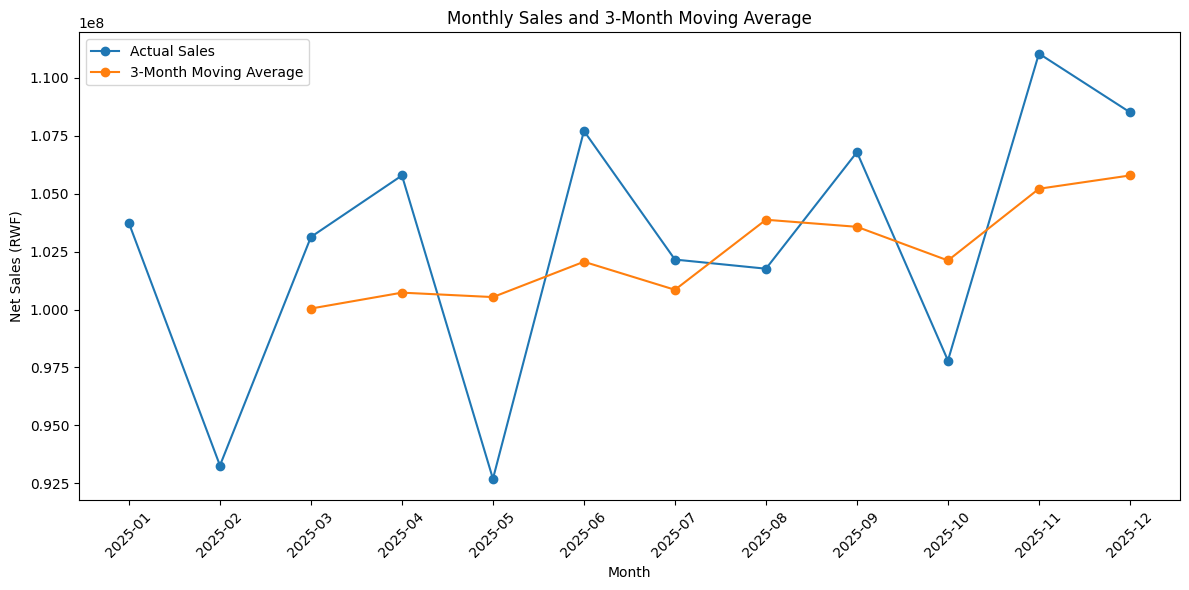

In [77]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["NetSales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_sales["Month"],
    monthly_sales["3_Month_Moving_Average"],
    marker="o",
    label="3-Month Moving Average"
)

plt.title("Monthly Sales and 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Net Sales (RWF)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
from sklearn.linear_model import LinearRegression

monthly_sales["Time"] = range(
    1,
    len(monthly_sales) + 1
)

X = monthly_sales[["Time"]]
y = monthly_sales["NetSales"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [79]:
next_period = len(monthly_sales) + 1

forecast = model.predict(
    [[next_period]]
)[0]

print(
    "Forecast for next month:",
    round(forecast, 2),
    "RWF"
)

Forecast for next month: 107452330.97 RWF


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [80]:
monthly_sales["Growth_Rate"] = (
    monthly_sales["NetSales"]
    .pct_change() * 100
)

monthly_sales

,TransactionDate,NetSales,Month,3_Month_Moving_Average,Time,Growth_Rate
0,2025-01,1.037253e+08,2025-01,NaN,1,NaN
1,2025-02,9.327233e+07,2025-02,NaN,2,-10.077590
2,2025-03,1.031316e+08,2025-03,1.000431e+08,3,10.570379
3,2025-04,1.057824e+08,2025-04,1.007288e+08,4,2.570323
4,2025-05,9.269844e+07,2025-05,1.005375e+08,5,-12.368735
5,2025-06,1.077024e+08,2025-06,1.020611e+08,6,16.185814
6,2025-07,1.021554e+08,2025-07,1.008521e+08,7,-5.150331
7,2025-08,1.017619e+08,2025-08,1.038732e+08,8,-0.385245
8,2025-09,1.067885e+08,2025-09,1.035686e+08,9,4.939578
9,2025-10,9.780096e+07,2025-10,1.021171e+08,10,-8.416178


In [81]:
highest_month = monthly_sales.loc[
    monthly_sales["NetSales"].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales["NetSales"].idxmin()
]

print("Highest month:")
print(highest_month)

print("\nLowest month:")
print(lowest_month)

Highest month:
TransactionDate                2025-11
NetSales                  111039953.86
Month                          2025-11
3_Month_Moving_Average    105209792.61
Time                                11
Growth_Rate                  13.536673
Name: 10, dtype: object

Lowest month:
TransactionDate                    2025-05
NetSales                        92698443.2
Month                              2025-05
3_Month_Moving_Average    100537467.186667
Time                                     5
Growth_Rate                     -12.368735
Name: 4, dtype: object


Step 9: Interpretation of Question 10

The monthly sales analysis shows variation in sales throughout 2025. November recorded the highest monthly net sales, while May recorded the lowest. The three-month moving average helps smooth short-term fluctuations and provides a clearer view of the general pattern. A simple linear regression model estimates next-period sales at approximately RWF 107.45 million. This forecast should be treated as an estimate because it is based only on historical sales and does not include external factors such as seasonality, promotions, economic conditions, inventory availability, or changes in customer behaviour.